<a href="https://colab.research.google.com/github/ellenwang995/PriceAtThePump/blob/main/PumpPrices.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

In [5]:
#Upload data
df = pd.read_excel("/content/NY_GasPrice.xlsx")
df.head()

,Date,NY_Gas,WTI
0,01/01/1986,1.205,22.93
1,02/01/1986,1.157,15.46
2,03/01/1986,1.022,12.61
3,04/01/1986,0.864,12.84
4,05/01/1986,0.860,15.38


In [9]:
#Set Date variable as a time variable
df['Date'] = pd.to_datetime(df['Date'], format='%m/%d/%Y')
df.dtypes

df = df.set_index('Date')
df.head()

,NY_Gas,WTI
Date,,
1986-01-01,1.205,22.93
1986-02-01,1.157,15.46
1986-03-01,1.022,12.61
1986-04-01,0.864,12.84
1986-05-01,0.860,15.38


# 1986-2026 Correlation and Regression Analysis

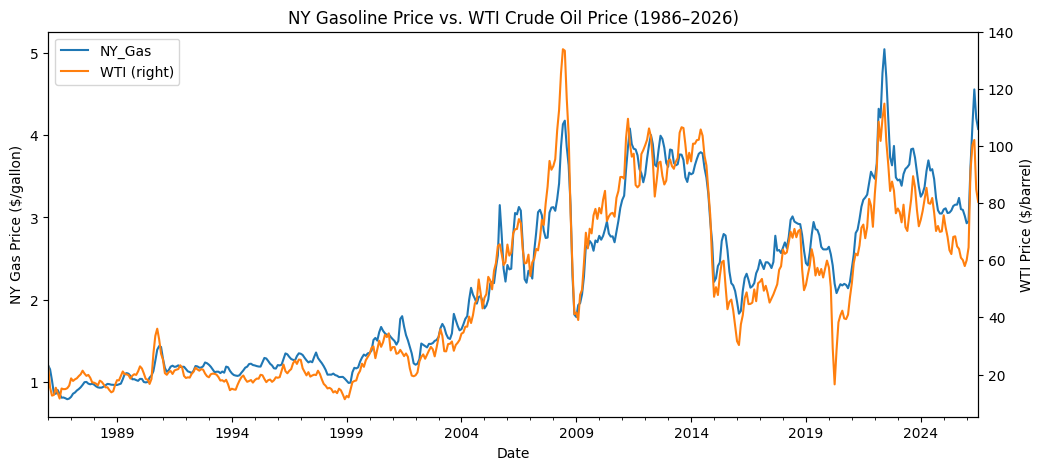

In [12]:
#plot data
ax = df[['NY_Gas', 'WTI']].plot(secondary_y='WTI', figsize=(12,5))

ax.set_title('NY Gasoline Price vs. WTI Crude Oil Price (1986–2026)')
ax.set_xlabel('Date')
ax.set_ylabel('NY Gas Price ($/gallon)')
ax.right_ax.set_ylabel('WTI Price ($/barrel)')

plt.show()

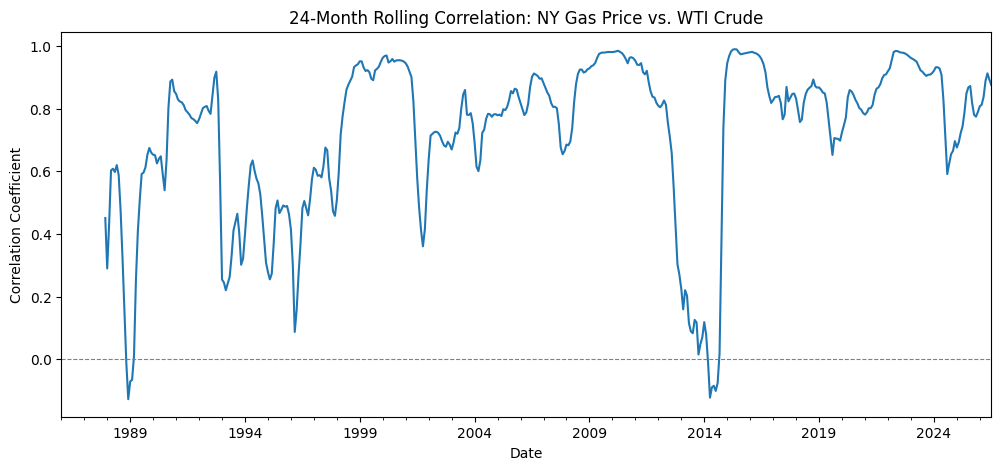

In [15]:
#correlation between WTI price and Gas Price
rolling_corr = df['NY_Gas'].rolling(24).corr(df['WTI'])

ax = rolling_corr.plot(figsize=(12,5))
ax.set_title('24-Month Rolling Correlation: NY Gas Price vs. WTI Crude')
ax.set_xlabel('Date')
ax.set_ylabel('Correlation Coefficient')
ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')  # reference line at 0

plt.show()

In [18]:
#Regression
X = sm.add_constant(df['WTI'])  # adds intercept term
y = df['NY_Gas']

model = sm.OLS(y, X, missing='drop').fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                 NY_Gas   R-squared:                       0.931
Model:                            OLS   Adj. R-squared:                  0.931
Method:                 Least Squares   F-statistic:                     6517.
Date:                Mon, 07 Sep 2026   Prob (F-statistic):          2.51e-283
Time:                        20:32:00   Log-Likelihood:                -47.730
No. Observations:                 487   AIC:                             99.46
Df Residuals:                     485   BIC:                             107.8
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.5773      0.023     24.691      0.0

# 2020-2026 Correlation and Regression Analysis

In [19]:
df_post2020 = df.loc['2020-01-01':'2026-12-31']

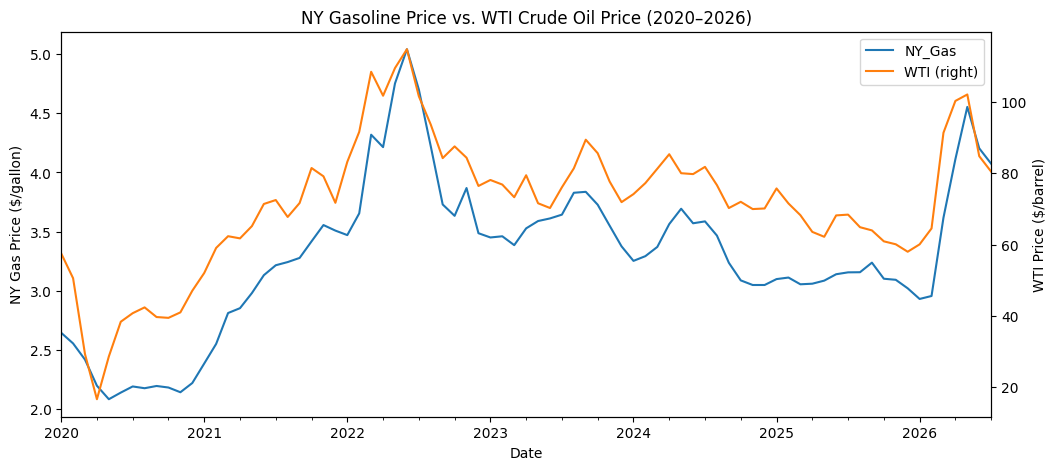

In [20]:
ax = df_post2020[['NY_Gas', 'WTI']].plot(secondary_y='WTI', figsize=(12,5))

ax.set_title('NY Gasoline Price vs. WTI Crude Oil Price (2020–2026)')
ax.set_xlabel('Date')
ax.set_ylabel('NY Gas Price ($/gallon)')
ax.right_ax.set_ylabel('WTI Price ($/barrel)')

plt.show()

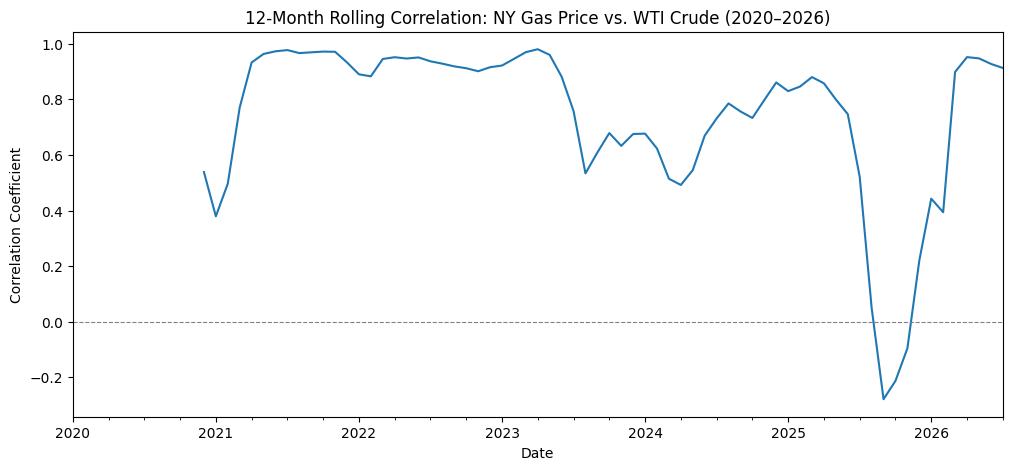

In [21]:
rolling_corr_post2020 = df_post2020['NY_Gas'].rolling(12).corr(df_post2020['WTI'])

ax = rolling_corr_post2020.plot(figsize=(12,5))
ax.set_title('12-Month Rolling Correlation: NY Gas Price vs. WTI Crude (2020–2026)')
ax.set_xlabel('Date')
ax.set_ylabel('Correlation Coefficient')
ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')

plt.show()

In [22]:
X_post2020 = sm.add_constant(df_post2020['WTI'])
y_post2020 = df_post2020['NY_Gas']

model_post2020 = sm.OLS(y_post2020, X_post2020, missing='drop').fit()
print(model_post2020.summary())

                            OLS Regression Results                            
Dep. Variable:                 NY_Gas   R-squared:                       0.891
Model:                            OLS   Adj. R-squared:                  0.890
Method:                 Least Squares   F-statistic:                     631.3
Date:                Mon, 07 Sep 2026   Prob (F-statistic):           7.55e-39
Time:                        20:37:21   Log-Likelihood:                 10.847
No. Observations:                  79   AIC:                            -17.69
Df Residuals:                      77   BIC:                            -12.95
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.9846      0.095     10.371      0.0